In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from astropy import units as u
import numpy as np
from disktab import AGNDisk
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from astropy.constants import G, c, sigma_sb, k_B, m_p

In [ ]:
disk = AGNDisk()

# Set required parameters
disk.M = 1e8 * u.Msun          # Central black hole mass
disk.Mdot = 1e23 * u.kg / u.s  # Mass accretion rate
disk.alpha = 0.1               # Shakura-Sunyaev viscosity parameter

mbh = 1*u.Msun
# Generate the disk profile
# rvals can be passed as dimensionless (assumed multiples of Rg) or with units
# If omitted, uses default: 200 log-spaced points from 10 to 10^7 Rg
#df = disk.spacehub_pretab(rvals=np.linspace(10, 10**7, 500))
df = disk.spacehub_pretab(rvals=np.logspace(1, 7, 200))
disk.model

,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,zone,grad_T,grad_Sigma
0,1.476625e+12,1.000000e+01,357328.173863,7.111188e-09,4.111521e+06,2.404530e+07,3.745240e+11,9.005542e+17,2663.310494,2.764415e+09,Standard,0.374998,0.091299
1,1.582782e+12,1.071891e+01,348145.509022,6.327184e-09,3.704900e+06,2.419820e+07,4.182719e+11,1.012143e+18,2646.482732,2.522799e+09,Standard,0.374999,-0.011222
2,1.696570e+12,1.148951e+01,339198.780970,5.792195e-09,3.338493e+06,2.400787e+07,4.605273e+11,1.105628e+18,2667.463739,2.237679e+09,Standard,0.375000,-0.195311
3,1.818538e+12,1.231551e+01,330481.937471,5.423920e-09,3.008321e+06,2.355079e+07,5.013412e+11,1.180698e+18,2719.234187,1.940329e+09,Standard,0.375001,-0.343287
4,1.949276e+12,1.320088e+01,321989.076991,5.173597e-09,2.710803e+06,2.289036e+07,5.407627e+11,1.237826e+18,2797.687908,1.651748e+09,Standard,0.375002,-0.464785
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1.118580e+18,7.575250e+06,92.144628,2.261124e-17,1.787543e-08,2.811681e+04,2.887427e+17,8.118524e+20,13.057662,1.000000e+00,Self-Reg,0.749621,1.499852
196,1.198997e+18,8.119845e+06,87.471808,1.835998e-17,1.451487e-08,2.811709e+04,3.204362e+17,9.009735e+20,11.766403,1.000000e+00,Self-Reg,0.749639,1.499857
197,1.285194e+18,8.703591e+06,83.035855,1.490802e-17,1.178608e-08,2.811737e+04,3.556083e+17,9.998771e+20,10.602830,1.000000e+00,Self-Reg,0.749656,1.499862
198,1.377588e+18,9.329304e+06,78.824770,1.210508e-17,9.570292e-09,2.811763e+04,3.946410e+17,1.109637e+21,9.554320,1.000000e+00,Self-Reg,0.749672,1.499866


In [ ]:
Rg = df['R/Rg'].values
R = df['R'].values * u.m
H = df['H'].values * u.m
rho = df['rho'].values * u.kg / u.m**3
Tc = df['Tc'].values * u.K
Sigma = df['Sigma'].values * u.kg / u.m**2
#Calculate Rosseland mean opacity
K0 = 0.4 * u.cm**2 / u.g                          # electron scattering
K1 = 6.4e22 * u.cm**5 / u.g**2 * u.K**(7/2)       # Kramers 

kappa = K0 + (K1 * rho * Tc**(-3.5))

#Calculate thermal diffusivity - assume adiabatic index 4/3 in radiation pressure zone and 5/3 in gas pressure zone 
P_rad = 4 * sigma_sb * Tc**4 / (3 * c)
P_gas = rho * k_B * Tc / (disk.mu * m_p)
#If P_rad > P_gas, 4/3
gamma = np.where(P_rad > P_gas, 4/3, 5/3)
Omega = np.sqrt(G * disk.M / R**3)
chi = 16 * gamma * (gamma - 1) * sigma_sb * Tc**4 / (3 * kappa * rho**2 * H**2 * Omega**2)

#Calculate f_gamma
x = (chi / (H**2 * Omega)).decompose().value

sqrt_halfx = np.sqrt(x/2)
f_gamma = (sqrt_halfx + 1/gamma) / (sqrt_halfx + 1)

#Calculate jm_lin_tot and jm_lin_iso coefficients 
#Linear total C_I = C_L + (0.46 - 0.96\Nabla_\Sigma + 1.8\Nabla_T) / \gamma
grad_T = df['grad_T'].values
grad_Sigma = df['grad_Sigma'].values

jm_lin_tot = -2.34 + (0.46 - 0.96 * grad_Sigma + 1.8 * grad_T) / gamma 
#Linear isothermal C_I = -1.36 - 0.54\Nabla_\Sigma - 0.5\Nabla_T
jm_lin_iso = -1.36 - (0.54 * grad_Sigma) - (0.5 * grad_T)

#Calc Gamma0
q = mbh/disk.M
Gamma0 = q**2 * Sigma * R**4 * Omega**2 * (H/R)**(-3)

#Calc net torque
GammaI_iso = jm_lin_iso * (H / R) * Gamma0
GammaI_tot = jm_lin_tot * (H / R) * Gamma0




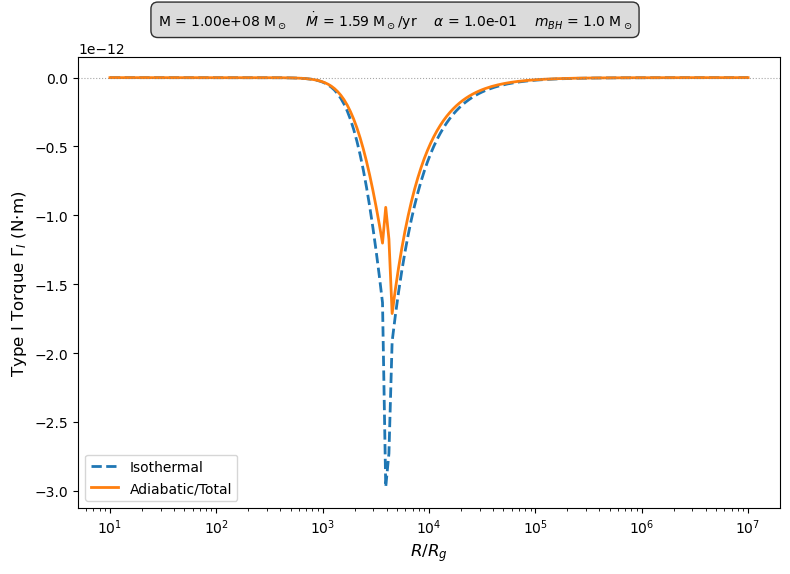

In [ ]:
from matplotlib.ticker import LogLocator, FuncFormatter

fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(x=Rg, y=GammaI_iso.value, ax=ax, label="Isothermal", linestyle="--", linewidth=2)
sns.lineplot(x=Rg, y=GammaI_tot.value, ax=ax, label="Adiabatic/Total", linewidth=2)

ax.set_xscale("log")

ax.set_xlabel(r"$R / R_g$", fontsize=12)
ax.set_ylabel(r"Type I Torque $\Gamma_I$ (N$\cdot$m)", fontsize=12)

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=10))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=100))

ax.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))

ax.legend(loc='best', fontsize=10)

ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)

M_str = f"{disk.M.to(u.Msun).value:.2e} M$_\\odot$"
Mdot_str = f"{disk.Mdot.to(u.Msun/u.yr).value:.2f} M$_\\odot$/yr"
alpha_str = f"{disk.alpha:.1e}"
mbh_str = f"{mbh.to(u.Msun).value:.1f} M$_\\odot$"

param_text = (
    f"M = {M_str}    "
    f"$\\dot{{M}}$ = {Mdot_str}    "
    f"$\\alpha$ = {alpha_str}    "
    f"$m_{{BH}}$ = {mbh_str}"
)

bbox_props = dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8, edgecolor='black')
fig.text(
    0.5, 0.95, param_text,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='center',
    bbox=bbox_props
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()